# End-to-End Financial Analysis and Forecasting

## Project Purpose

This notebook presents a full financial analysis workflow using simulated company data. 

The analysis answers practical business questions:

1. What is driving revenue?
2. What is driving profit?
3. Which products and regions are most profitable?
4. Where is the company beating or missing budget?
5. Are discounts helping or hurting profitability?
6. Which customers are most valuable?
7. How efficiently does the company convert sales into cash?
8. Can monthly revenue be forecasted (in the second notebook)?
9. What actions should management take?

The project uses invoice-level data, monthly budget data, financial statement data, and macroeconomic indicators.

In [1]:
# !conda install -c conda-forge openpyxl -y

### 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

# Basic
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid")

### 2. Load the Data

This project uses four related datasets.

1. `simulated_financial_transactions.csv`: invoice-level data
2. `monthly_budget_targets.csv`: budgeted revenue and costs
3. `monthly_financial_statements.csv`: monthly accounting and cash flow metrics
4. `macro_indicators_monthly.csv`: external variables for forecasting

In [2]:
# Project folders
DATA_DIR = Path("../data")
FIGURES_DIR = Path("../figures")
OUTPUTS_DIR = Path("../outputs")

FIGURES_DIR.mkdir(exist_ok=True)
OUTPUTS_DIR.mkdir(exist_ok=True)

transactions = pd.read_csv(DATA_DIR / "simulated_financial_transactions.csv")
budget = pd.read_csv(DATA_DIR / "monthly_budget_targets.csv")
financials = pd.read_csv(DATA_DIR / "monthly_financial_statements.csv")
macro = pd.read_csv(DATA_DIR / "macro_indicators_monthly.csv")

print("Transactions shape:", transactions.shape)
print("Budget shape:", budget.shape)
print("Financial statements shape:", financials.shape)
print("Macro indicators shape:", macro.shape)

Transactions shape: (120300, 21)
Budget shape: (1440, 8)
Financial statements shape: (72, 26)
Macro indicators shape: (72, 7)


In [3]:
transactions.head()

,invoice_id,invoice_date,fiscal_year,fiscal_month,region,product_line,sales_channel,customer_segment,industry,customer_id,sales_rep_id,units,unit_price,discount_rate,net_revenue,cogs,gross_profit,gross_margin_pct,payment_terms,days_to_collect,is_returned
0,1,2023-09-08,2023,9,North America,Data Platform,Direct Sales,SMB,Retail,119927,545,2,"2,240.67",0.05,"3,063.72",808.38,"2,255.34",0.74,90,99.10,0
1,2,2023-01-27,2023,1,North America,Data Platform,Partner,SMB,Retail,110883,545,4,"2,217.11",0.05,"6,064.06","2,237.89","3,826.16",0.63,15,14.10,0
2,3,2024-11-01,2024,11,North America,Professional Services,Direct Sales,SMB,Education,128755,523,3,"1,699.93",0.14,"3,140.53","1,917.16","1,223.38",0.39,30,33.20,0
3,4,2025-11-24,2025,11,Europe,Subscription,Direct Sales,SMB,Retail,117634,562,2,"1,035.47",0.08,"1,374.94",341.35,"1,033.60",0.75,15,16.70,0
4,5,2023-02-21,2023,2,Latin America,Professional Services,Enterprise Account,Mid-Market,Manufacturing,115491,599,3,"2,293.54",0.06,"6,474.79","4,042.89","2,431.90",0.38,15,17.10,0


### 3. Initial Data Inspection

Before doing any financial analysis, a professional analyst should inspect the data for:

- Missing values
- Duplicate rows
- Incorrect data types
- Inconsistent categorical values
- Outliers
- Date problems

In [4]:
def inspect_dataframe(df, name):
    print(f"\n=================={name.upper()} =====================")
    print("Shape:", df.shape)
    print("\nData types:")
    print(df.dtypes)
    print("\nMissing Values:")
    print(df.isna().sum().sort_values(ascending=False).head())
    print("\nDuplicate rows:", df.duplicated().sum())

inspect_dataframe(transactions, "transactions")
inspect_dataframe(budget, "budget")
inspect_dataframe(financials, "financials")
inspect_dataframe(macro, "macro")


==================TRANSACTIONS =====================
Shape: (120300, 21)

Data types:
invoice_id            int64
invoice_date            str
fiscal_year           int64
fiscal_month          int64
region                  str
product_line            str
sales_channel           str
customer_segment        str
industry                str
customer_id           int64
sales_rep_id          int64
units                 int64
unit_price          float64
discount_rate       float64
net_revenue         float64
cogs                float64
gross_profit        float64
gross_margin_pct    float64
payment_terms         int64
days_to_collect     float64
is_returned           int64
dtype: object

Missing Values:
gross_margin_pct    1806
days_to_collect     1805
discount_rate       1805
invoice_id             0
units                  0
dtype: int64

Duplicate rows: 300

==================BUDGET =====================
Shape: (1440, 8)

Data types:
month                       str
region                   

### 4. Data Cleaning

Cleaning steps:

1. Convert date columns to datetime.
2. Remove duplicate invoice rows.
3. Standardize text columns.
4. Fill missing financial rates with appropriate values.
5. Recalculate gross margin where needed.
6. Create monthly date variables.

In [5]:
# Convert dates
transactions["invoice_date"] = pd.to_datetime(transactions["invoice_date"])
budget["month"] = pd.to_datetime(budget["month"])
financials["month"] = pd.to_datetime(financials["month"])
macro["month"] = pd.to_datetime(macro["month"])

In [6]:
# Remove duplicates in transactions
before = len(transactions)
transactions = transactions.drop_duplicates()
after = len(transactions)

print(f"Duplicate rows removed: {before - after}")

Duplicate rows removed: 300


In [7]:
# Clean the text columns (not needed)
text_cols = transactions.select_dtypes(include='object').columns

for col in text_cols:
    transactions[col] = transactions[col].str.strip().str.title()

In [8]:
# Fill missing values with their median
transactions["discount_rate"] = transactions["discount_rate"].fillna(
    transactions["discount_rate"].median())

# Fill missing days to collect by payment terms group with median
transactions["days_to_collect"] = transactions.groupby("payment_terms")["days_to_collect"].transform(
    lambda x: x.fillna(x.median())) # For every group, calculates the median to fill NA

transactions["gross_margin_pct"] = transactions["gross_margin_pct"].fillna(
    transactions["gross_profit"] / transactions["net_revenue"]) # recalculate gross margin where missing

In [9]:
# create time variables
transactions["month"] = transactions["invoice_date"].dt.to_period("M").dt.to_timestamp()
transactions["year"] = transactions["invoice_date"].dt.year
transactions["quarter"] = transactions["invoice_date"].dt.quarter
transactions["month_name"] = transactions["invoice_date"].dt.month_name()

In [10]:
# Save Cleaned data
transactions.to_csv(OUTPUTS_DIR / "cleaned_financial_transactions.csv", index = False)
transactions.head()

,invoice_id,invoice_date,fiscal_year,fiscal_month,region,product_line,sales_channel,customer_segment,industry,customer_id,sales_rep_id,units,unit_price,discount_rate,net_revenue,cogs,gross_profit,gross_margin_pct,payment_terms,days_to_collect,is_returned,month,year,quarter,month_name
0,1,2023-09-08,2023,9,North America,Data Platform,Direct Sales,Smb,Retail,119927,545,2,"2,240.67",0.05,"3,063.72",808.38,"2,255.34",0.74,90,99.10,0,2023-09-01,2023,3,September
1,2,2023-01-27,2023,1,North America,Data Platform,Partner,Smb,Retail,110883,545,4,"2,217.11",0.05,"6,064.06","2,237.89","3,826.16",0.63,15,14.10,0,2023-01-01,2023,1,January
2,3,2024-11-01,2024,11,North America,Professional Services,Direct Sales,Smb,Education,128755,523,3,"1,699.93",0.14,"3,140.53","1,917.16","1,223.38",0.39,30,33.20,0,2024-11-01,2024,4,November
3,4,2025-11-24,2025,11,Europe,Subscription,Direct Sales,Smb,Retail,117634,562,2,"1,035.47",0.08,"1,374.94",341.35,"1,033.60",0.75,15,16.70,0,2025-11-01,2025,4,November
4,5,2023-02-21,2023,2,Latin America,Professional Services,Enterprise Account,Mid-Market,Manufacturing,115491,599,3,"2,293.54",0.06,"6,474.79","4,042.89","2,431.90",0.38,15,17.10,0,2023-02-01,2023,1,February


### KPI Summary

Key metrics include:

- Revenue
- COGS
- Gross profit
- Gross margin
- EBITDA
- EBITDA margin
- Net income
- Net margin
- Free cash flow
- Return rate
- Days to collect

In [11]:
financials.head()

,month,revenue,cogs,gross_profit,units,active_customers,return_rate,avg_days_to_collect,sales_marketing_expense,r_and_d_expense,g_and_a_expense,total_opex,ebitda,depreciation_amortization,operating_income,interest_expense,tax_expense,net_income,accounts_receivable,inventory,accounts_payable,capex,free_cash_flow,gross_margin,ebitda_margin,net_margin
0,2020-01-01,"7,876,820.54","3,853,402.07","4,023,418.54",6599,1691,0.05,50.45,"1,185,084.94","633,567.35","956,421.25","2,775,073.54","1,248,345.00","192,734.55","1,055,610.45","88,969.38","170,190.05","796,451.02","13,245,047.65","2,712,945.98","1,794,554.01","365,914.29","623,271.28",0.51,0.16,0.10
1,2020-02-01,"8,249,437.24","4,057,691.40","4,191,745.55",6376,1611,0.04,49.75,"1,256,457.88","771,306.84","884,015.96","2,911,780.68","1,279,964.87","298,538.90","981,425.97","116,661.57","143,872.99","720,891.41","13,681,145.42","2,802,054.43","2,300,415.33","519,026.87","481,058.54",0.51,0.16,0.09
2,2020-03-01,"8,537,230.51","4,224,043.52","4,313,186.96",6555,1673,0.05,50.45,"1,576,113.32","985,662.71","1,164,898.99","3,726,675.02","586,511.94","247,757.66","338,754.28","99,270.72","44,337.33","195,146.23","14,356,658.80","2,880,638.48","1,614,668.60","322,269.99","-1,319,210.26",0.51,0.07,0.02
3,2020-04-01,"8,159,591.71","3,959,527.24","4,200,064.61",6315,1622,0.04,50.09,"1,420,251.51","721,040.54","1,094,596.09","3,235,888.14","964,176.47","262,129.79","702,046.68","50,312.20","149,230.13","502,504.35","13,623,132.78","2,686,172.26","1,860,299.39","158,456.15","1,779,801.02",0.51,0.12,0.06
4,2020-05-01,"8,828,964.24","4,219,678.52","4,609,285.86",6714,1649,0.04,49.90,"1,456,139.49","923,516.63","1,077,155.15","3,456,811.27","1,152,474.59","153,441.36","999,033.23","63,455.30","208,817.83","726,760.10","14,685,194.07","2,623,922.59","1,743,433.26","460,418.39","-696,894.68",0.52,0.13,0.08


In [12]:
# current year KPI
latest_year = financials["month"].dt.year.max()

fy_summary = financials[financials["month"].dt.year == latest_year].agg({
    "revenue": "sum",
    "cogs": "sum",
    "gross_profit": "sum",
    "ebitda": "sum",
    "net_income": "sum",
    "free_cash_flow": "sum",
    "return_rate": "mean",
    "avg_days_to_collect": "mean"
})

executive_kpis = pd.DataFrame({
    "Metric": [
        "Fiscal Year",
        "Revenue",
        "COGS",
        "Gross Profit",
        "Gross Margin",
        "EBITDA",
        "EBITDA Margin",
        "Net Income",
        "Net Margin",
        "Free Cash Flow",
        "Return Rate",
        "Average Days to Collect"
    ],
    "Value": [
        latest_year,
        fy_summary["revenue"],
        fy_summary["cogs"],
        fy_summary["gross_profit"],
        fy_summary["gross_profit"] / fy_summary["revenue"],
        fy_summary["ebitda"],
        fy_summary["ebitda"] / fy_summary["revenue"],
        fy_summary["net_income"],
        fy_summary["net_income"] / fy_summary["revenue"],
        fy_summary["free_cash_flow"],
        fy_summary["return_rate"],
        fy_summary["avg_days_to_collect"]
    ]
})

executive_kpis.to_csv(OUTPUTS_DIR / "executive_kpi_summary.csv", index=False)
executive_kpis

,Metric,Value
0,Fiscal Year,"2,025.00"
1,Revenue,"119,066,348.74"
2,COGS,"57,650,849.44"
3,Gross Profit,"61,415,499.17"
4,Gross Margin,0.52
5,EBITDA,"16,046,363.94"
6,EBITDA Margin,0.13
7,Net Income,"9,497,892.41"
8,Net Margin,0.08
9,Free Cash Flow,"6,272,770.87"


### Revenue Analysis

We analyze revenue by:

- Product line
- Region
- Sales channel
- Customer segment
- Industry

The goal is to understand growth drivers and resource allocation.

In [13]:
transactions.head()

,invoice_id,invoice_date,fiscal_year,fiscal_month,region,product_line,sales_channel,customer_segment,industry,customer_id,sales_rep_id,units,unit_price,discount_rate,net_revenue,cogs,gross_profit,gross_margin_pct,payment_terms,days_to_collect,is_returned,month,year,quarter,month_name
0,1,2023-09-08,2023,9,North America,Data Platform,Direct Sales,Smb,Retail,119927,545,2,"2,240.67",0.05,"3,063.72",808.38,"2,255.34",0.74,90,99.10,0,2023-09-01,2023,3,September
1,2,2023-01-27,2023,1,North America,Data Platform,Partner,Smb,Retail,110883,545,4,"2,217.11",0.05,"6,064.06","2,237.89","3,826.16",0.63,15,14.10,0,2023-01-01,2023,1,January
2,3,2024-11-01,2024,11,North America,Professional Services,Direct Sales,Smb,Education,128755,523,3,"1,699.93",0.14,"3,140.53","1,917.16","1,223.38",0.39,30,33.20,0,2024-11-01,2024,4,November
3,4,2025-11-24,2025,11,Europe,Subscription,Direct Sales,Smb,Retail,117634,562,2,"1,035.47",0.08,"1,374.94",341.35,"1,033.60",0.75,15,16.70,0,2025-11-01,2025,4,November
4,5,2023-02-21,2023,2,Latin America,Professional Services,Enterprise Account,Mid-Market,Manufacturing,115491,599,3,"2,293.54",0.06,"6,474.79","4,042.89","2,431.90",0.38,15,17.10,0,2023-02-01,2023,1,February


In [14]:
revenue_by_product = (
    transactions
    .groupby("product_line", as_index=False)
    .agg(
        revenue=("net_revenue", "sum"),
        gross_profit=("gross_profit", "sum"),
        units=("units", "sum"),
        avg_discount=("discount_rate", "mean"),
        return_rate=("is_returned", "mean"),
        customers=("customer_id", "nunique")
    )
)

revenue_by_product["gross_margin"] = revenue_by_product["gross_profit"] / revenue_by_product["revenue"]
revenue_by_product["revenue_share"] = revenue_by_product["revenue"] / revenue_by_product["revenue"].sum()
revenue_by_product = revenue_by_product.sort_values("revenue", ascending=False)

revenue_by_product.to_csv(OUTPUTS_DIR / "revenue_by_product_line.csv", index=False)
revenue_by_product

,product_line,revenue,gross_profit,units,avg_discount,return_rate,customers,gross_margin,revenue_share
3,Subscription,"184,081,252.02","127,966,509.95",193051,0.16,0.04,24386,0.70,0.29
0,Data Platform,"182,259,028.22","115,759,317.81",73583,0.16,0.04,14198,0.64,0.28
1,Hardware,"133,607,479.41","28,964,168.45",65304,0.16,0.08,12927,0.22,0.21
2,Professional Services,"117,028,546.80","43,473,983.55",82899,0.16,0.04,15474,0.37,0.18
4,Support,"23,615,962.46","12,636,735.95",46324,0.16,0.04,9867,0.54,0.04


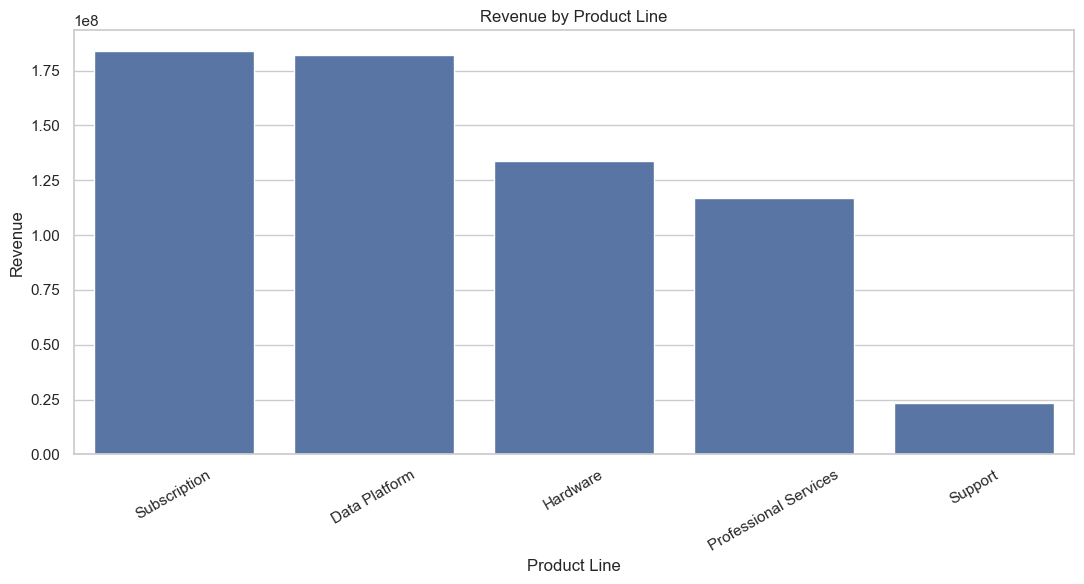

In [15]:
plt.figure(figsize=(11, 6))
sns.barplot(
    data=revenue_by_product,
    x="product_line",
    y="revenue"
)
plt.title("Revenue by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Revenue")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "revenue_by_product_line.png", dpi=300)
plt.show()

In [16]:
revenue_by_region = (
    transactions
    .groupby("region", as_index=False)
    .agg(
        revenue=("net_revenue", "sum"),
        gross_profit=("gross_profit", "sum"),
        customers=("customer_id", "nunique"),
        avg_days_to_collect=("days_to_collect", "mean"),
        return_rate=("is_returned", "mean")
    )
)

revenue_by_region["gross_margin"] = revenue_by_region["gross_profit"] / revenue_by_region["revenue"]
revenue_by_region = revenue_by_region.sort_values("revenue", ascending=False)

revenue_by_region.to_csv(OUTPUTS_DIR / "revenue_by_region.csv", index=False)
revenue_by_region

,region,revenue,gross_profit,customers,avg_days_to_collect,return_rate,gross_margin
3,North America,"326,639,848.00","167,317,331.43",25620,49.57,0.04,0.51
1,Europe,"157,325,786.96","80,926,010.67",19102,49.77,0.05,0.51
0,Asia Pacific,"108,285,194.14","55,832,510.00",15436,49.71,0.04,0.52
2,Latin America,"48,341,439.81","24,724,863.61",9207,56.42,0.04,0.51


In [17]:
transactions.head()

,invoice_id,invoice_date,fiscal_year,fiscal_month,region,product_line,sales_channel,customer_segment,industry,customer_id,sales_rep_id,units,unit_price,discount_rate,net_revenue,cogs,gross_profit,gross_margin_pct,payment_terms,days_to_collect,is_returned,month,year,quarter,month_name
0,1,2023-09-08,2023,9,North America,Data Platform,Direct Sales,Smb,Retail,119927,545,2,"2,240.67",0.05,"3,063.72",808.38,"2,255.34",0.74,90,99.10,0,2023-09-01,2023,3,September
1,2,2023-01-27,2023,1,North America,Data Platform,Partner,Smb,Retail,110883,545,4,"2,217.11",0.05,"6,064.06","2,237.89","3,826.16",0.63,15,14.10,0,2023-01-01,2023,1,January
2,3,2024-11-01,2024,11,North America,Professional Services,Direct Sales,Smb,Education,128755,523,3,"1,699.93",0.14,"3,140.53","1,917.16","1,223.38",0.39,30,33.20,0,2024-11-01,2024,4,November
3,4,2025-11-24,2025,11,Europe,Subscription,Direct Sales,Smb,Retail,117634,562,2,"1,035.47",0.08,"1,374.94",341.35,"1,033.60",0.75,15,16.70,0,2025-11-01,2025,4,November
4,5,2023-02-21,2023,2,Latin America,Professional Services,Enterprise Account,Mid-Market,Manufacturing,115491,599,3,"2,293.54",0.06,"6,474.79","4,042.89","2,431.90",0.38,15,17.10,0,2023-02-01,2023,1,February


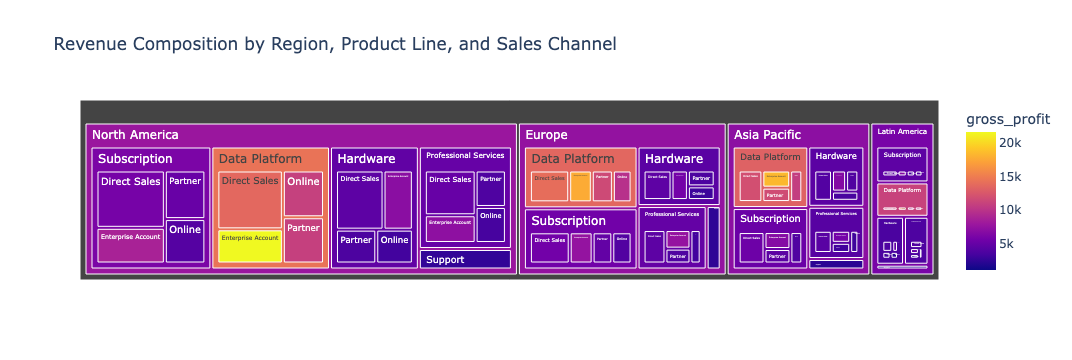

In [18]:
fig = px.treemap(
    transactions,
    path=["region", "product_line", "sales_channel"],
    values="net_revenue",
    color="gross_profit",
    title="Revenue Composition by Region, Product Line, and Sales Channel"
)

fig.show()

# Save interactive and static outputs
fig.write_html(FIGURES_DIR / "revenue_composition_treemap.html")
fig.write_image(FIGURES_DIR / "revenue_composition_treemap.png", width=1100, height=700)

### Profitability Analysis
Revenue growth is not enough. We need to know whether revenue is profitable.

Here, we compare revenue and gross margin by product line. A product may have high sales but weak margin, which may require pricing changes, supplier negotiations, or discount controls.

In [19]:
revenue_by_product.head()

,product_line,revenue,gross_profit,units,avg_discount,return_rate,customers,gross_margin,revenue_share
3,Subscription,"184,081,252.02","127,966,509.95",193051,0.16,0.04,24386,0.70,0.29
0,Data Platform,"182,259,028.22","115,759,317.81",73583,0.16,0.04,14198,0.64,0.28
1,Hardware,"133,607,479.41","28,964,168.45",65304,0.16,0.08,12927,0.22,0.21
2,Professional Services,"117,028,546.80","43,473,983.55",82899,0.16,0.04,15474,0.37,0.18
4,Support,"23,615,962.46","12,636,735.95",46324,0.16,0.04,9867,0.54,0.04


In [20]:
profitability = revenue_by_product.copy()

portfolio_gross_margin = transactions["gross_profit"].sum() / transactions["net_revenue"].sum()

profitability["margin_gap_vs_portfolio"] = profitability["gross_margin"] - portfolio_gross_margin
profitability["high_revenue_weak_margin"] = (
    (profitability["revenue_share"] > profitability["revenue_share"].median()) &
    (profitability["gross_margin"] < portfolio_gross_margin)
)

profitability.to_csv(OUTPUTS_DIR / "profitability_by_product_line.csv", index=False)
profitability

,product_line,revenue,gross_profit,units,avg_discount,return_rate,customers,gross_margin,revenue_share,margin_gap_vs_portfolio,high_revenue_weak_margin
3,Subscription,"184,081,252.02","127,966,509.95",193051,0.16,0.04,24386,0.70,0.29,0.18,False
0,Data Platform,"182,259,028.22","115,759,317.81",73583,0.16,0.04,14198,0.64,0.28,0.12,False
1,Hardware,"133,607,479.41","28,964,168.45",65304,0.16,0.08,12927,0.22,0.21,-0.30,False
2,Professional Services,"117,028,546.80","43,473,983.55",82899,0.16,0.04,15474,0.37,0.18,-0.14,False
4,Support,"23,615,962.46","12,636,735.95",46324,0.16,0.04,9867,0.54,0.04,0.02,False


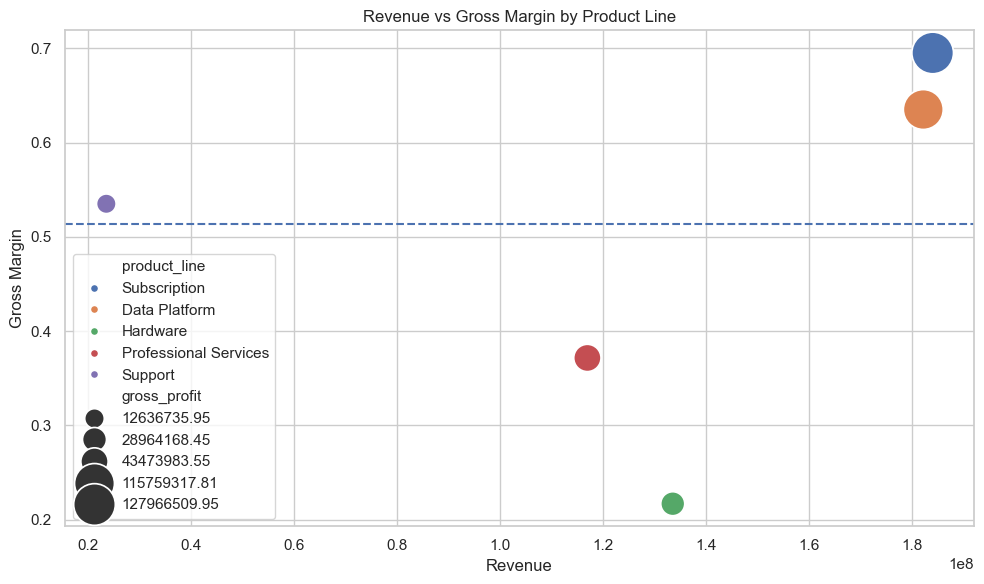

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=profitability,
    x="revenue",
    y="gross_margin",
    size="gross_profit",
    hue="product_line",
    sizes=(200, 900)
)

plt.axhline(portfolio_gross_margin, linestyle="--")
plt.title("Revenue vs Gross Margin by Product Line")
plt.xlabel("Revenue")
plt.ylabel("Gross Margin")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "revenue_vs_margin_by_product.png", dpi=300)
plt.show()

### Discount Analysis
Discounting can increase sales volume, but it can also weaken margins and increase low-quality demand.

We group transactions into discount bands and compare:

- Average revenue
- Average gross margin
- Return rate
- Days to collect

In [22]:
transactions["discount_band"] = pd.cut(
    transactions["discount_rate"],
    bins=[-0.001, 0.05, 0.10, 0.20, 0.30, 1.00],
    labels=["0-5%", "5-10%", "10-20%", "20-30%", "30%+"]
)

discount_analysis = (
    transactions
    .groupby("discount_band", observed=False)
    .agg(
        revenue=("net_revenue", "sum"),
        avg_invoice_revenue=("net_revenue", "mean"),
        gross_margin=("gross_margin_pct", "mean"),
        return_rate=("is_returned", "mean"),
        avg_days_to_collect=("days_to_collect", "mean"),
        invoices=("invoice_id", "nunique")
    )
    .reset_index()
)

discount_analysis.to_csv(OUTPUTS_DIR / "discount_analysis.csv", index=False)
discount_analysis

,discount_band,revenue,avg_invoice_revenue,gross_margin,return_rate,avg_days_to_collect,invoices
0,0-5%,"61,896,156.11","4,462.59",0.40,0.03,48.15,13870
1,5-10%,"142,826,166.64","5,727.25",-0.06,0.04,50.11,24938
2,10-20%,"253,437,463.88","5,776.62",0.29,0.04,50.44,43873
3,20-30%,"119,462,000.77","5,198.07",-0.27,0.06,50.89,22982
4,30%+,"62,970,481.51","4,392.17",0.04,0.06,51.10,14337


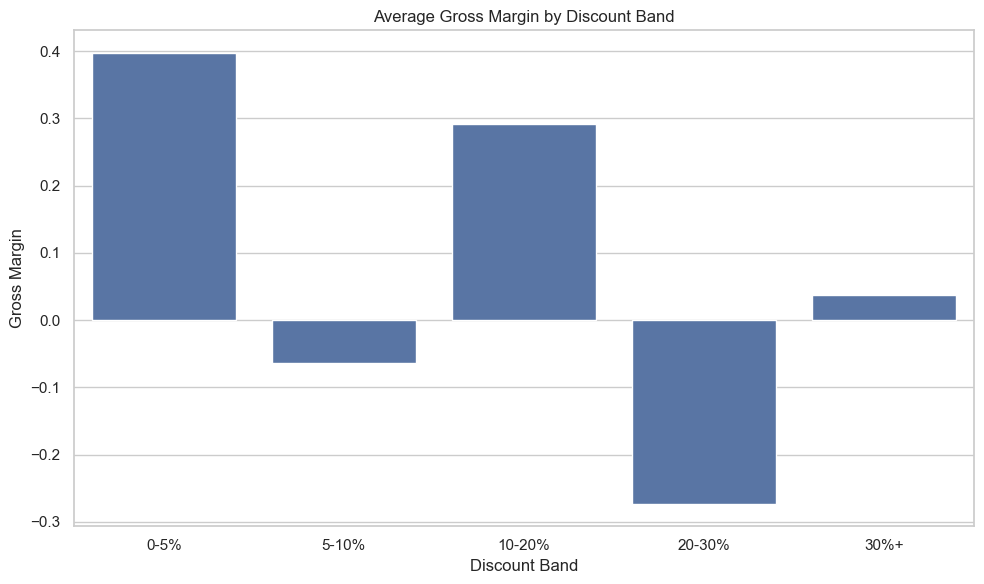

In [23]:
plt.figure(figsize=(10, 6))
sns.barplot(data=discount_analysis, x="discount_band", y="gross_margin")
plt.title("Average Gross Margin by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Gross Margin")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "gross_margin_by_discount_band.png", dpi=300)
plt.show()

### Budget vs Actual Variance Analysis

Budget variance analysis is central to FP&A work.

We compare actuals to budget by month, region, and product line.

Important variance formulas:

- Revenue variance = Actual revenue minus Budget revenue
- Revenue variance percent = Actual revenue divided by Budget revenue minus 1
- Gross profit variance = Actual gross profit minus Budget gross profit
- Positive variance is favorable for revenue and profit. Positive COGS variance is usually unfavorable if actual costs exceed budget.

In [24]:
actual_monthly_detail = (
    transactions
    .groupby(["month", "region", "product_line"], as_index=False)
    .agg(
        actual_revenue=("net_revenue", "sum"),
        actual_cogs=("cogs", "sum"),
        actual_gross_profit=("gross_profit", "sum"),
        actual_units=("units", "sum")
    )
)

variance = actual_monthly_detail.merge(
    budget,
    on=["month", "region", "product_line"],
    how="left"
)

variance["revenue_variance"] = variance["actual_revenue"] - variance["budget_revenue"]
variance["revenue_variance_pct"] = variance["actual_revenue"] / variance["budget_revenue"] - 1

variance["cogs_variance"] = variance["actual_cogs"] - variance["budget_cogs"]
variance["gross_profit_variance"] = variance["actual_gross_profit"] - variance["budget_gross_profit"]
variance["gross_profit_variance_pct"] = variance["actual_gross_profit"] / variance["budget_gross_profit"] - 1

variance["unit_variance"] = variance["actual_units"] - variance["budget_units"]

variance.to_csv(OUTPUTS_DIR / "budget_vs_actual_variance.csv", index=False)

variance.head()

,month,region,product_line,actual_revenue,actual_cogs,actual_gross_profit,actual_units,budget_revenue,budget_cogs,budget_gross_profit,budget_units,budget_discount_rate,revenue_variance,revenue_variance_pct,cogs_variance,gross_profit_variance,gross_profit_variance_pct,unit_variance
0,2020-01-01,Asia Pacific,Data Platform,"385,629.18","147,075.78","238,553.38",194,"419,900.38","148,827.80","271,072.58",208,0.18,"-34,271.20",-0.08,"-1,752.02","-32,519.20",-0.12,-14
1,2020-01-01,Asia Pacific,Hardware,"271,563.46","231,318.22","40,245.21",163,"229,671.57","249,534.23","-19,862.66",149,0.13,"41,891.89",0.18,"-18,216.01","60,107.87",-3.03,14
2,2020-01-01,Asia Pacific,Professional Services,"308,646.23","189,568.77","119,077.41",236,"290,638.87","175,697.06","114,941.81",223,0.14,"18,007.36",0.06,"13,871.71","4,135.60",0.04,13
3,2020-01-01,Asia Pacific,Subscription,"397,271.85","118,885.39","278,386.48",521,"357,806.72","144,163.36","213,643.36",494,0.17,"39,465.13",0.11,"-25,277.97","64,743.12",0.30,27
4,2020-01-01,Asia Pacific,Support,"55,427.40","25,595.10","29,832.32",121,"62,573.33","23,256.41","39,316.92",125,0.15,"-7,145.93",-0.11,"2,338.69","-9,484.60",-0.24,-4


In [25]:
variance_summary = (
    variance
    .groupby("product_line", as_index=False)
    .agg(
        actual_revenue=("actual_revenue", "sum"),
        budget_revenue=("budget_revenue", "sum"),
        revenue_variance=("revenue_variance", "sum"),
        actual_gross_profit=("actual_gross_profit", "sum"),
        budget_gross_profit=("budget_gross_profit", "sum"),
        gross_profit_variance=("gross_profit_variance", "sum")
    )
)

variance_summary["revenue_variance_pct"] = (
    variance_summary["actual_revenue"] / variance_summary["budget_revenue"] - 1
)

variance_summary["gross_profit_variance_pct"] = (
    variance_summary["actual_gross_profit"] / variance_summary["budget_gross_profit"] - 1
)

variance_summary = variance_summary.sort_values("revenue_variance", ascending=False)

variance_summary.to_csv(OUTPUTS_DIR / "budget_variance_summary_by_product.csv", index=False)
variance_summary

,product_line,actual_revenue,budget_revenue,revenue_variance,actual_gross_profit,budget_gross_profit,gross_profit_variance,revenue_variance_pct,gross_profit_variance_pct
4,Support,"23,615,962.46","24,522,705.04","-906,742.58","12,636,735.95","13,522,236.51","-885,500.56",-0.04,-0.07
2,Professional Services,"117,028,546.80","121,545,643.51","-4,517,096.71","43,473,983.55","47,456,044.56","-3,982,061.01",-0.04,-0.08
1,Hardware,"133,607,479.41","138,315,949.55","-4,708,470.14","28,964,168.45","34,337,812.26","-5,373,643.81",-0.03,-0.16
3,Subscription,"184,081,252.02","191,653,654.77","-7,572,402.75","127,966,509.95","135,303,962.80","-7,337,452.85",-0.04,-0.05
0,Data Platform,"182,259,028.22","189,991,334.08","-7,732,305.86","115,759,317.81","123,443,432.27","-7,684,114.46",-0.04,-0.06


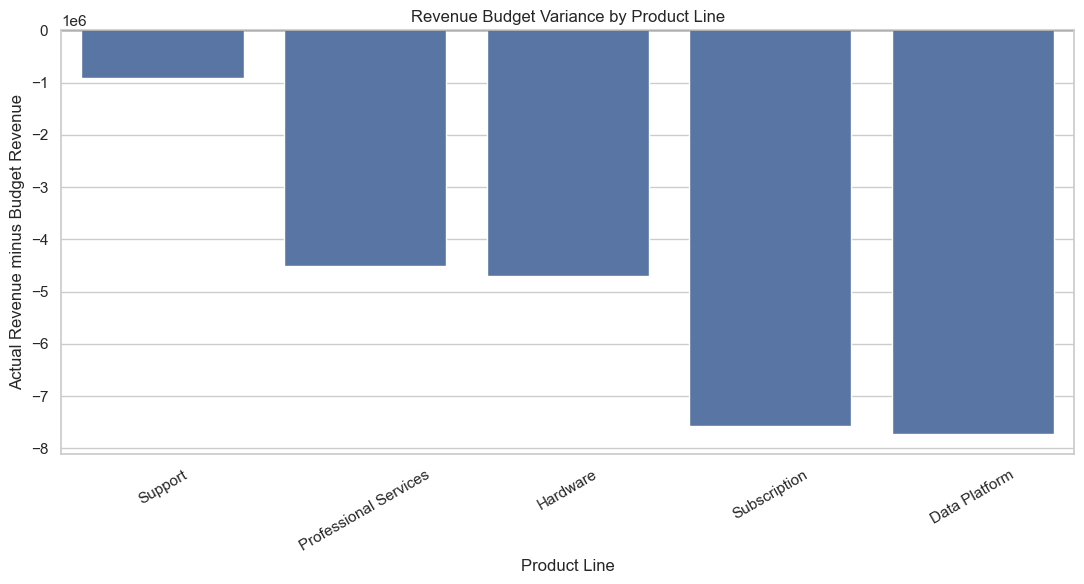

In [26]:
plt.figure(figsize=(11, 6))
sns.barplot(
    data=variance_summary,
    x="product_line",
    y="revenue_variance"
)
plt.axhline(0, color="black", linewidth=1)
plt.title("Revenue Budget Variance by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Actual Revenue minus Budget Revenue")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "budget_variance_by_product_line.png", dpi=300)
plt.show()

### Customer Concentration Analysis
Customer concentration is important because high dependence on a few customers increases business risk.

We want to examine the following:

- Top customers by revenue
- Revenue share from top 10 customers
- Revenue share from top 100 customers
- Average margin by customer segment

In [27]:
customer_summary = (
    transactions
    .groupby("customer_id", as_index=False)
    .agg(
        revenue=("net_revenue", "sum"),
        gross_profit=("gross_profit", "sum"),
        invoices=("invoice_id", "nunique"),
        avg_discount=("discount_rate", "mean"),
        avg_days_to_collect=("days_to_collect", "mean"),
        return_rate=("is_returned", "mean")
    )
)

customer_summary["gross_margin"] = customer_summary["gross_profit"] / customer_summary["revenue"]
customer_summary = customer_summary.sort_values("revenue", ascending=False)

total_revenue = customer_summary["revenue"].sum()
top_10_share = customer_summary.head(10)["revenue"].sum() / total_revenue
top_100_share = customer_summary.head(100)["revenue"].sum() / total_revenue

print(f"Top 10 customer revenue share: {top_10_share:.2%}")
print(f"Top 100 customer revenue share: {top_100_share:.2%}")

customer_summary.head(20).to_csv(OUTPUTS_DIR / "top_20_customers.csv", index=False)
customer_summary.head(5)

Top 10 customer revenue share: 0.34%
Top 100 customer revenue share: 1.98%


,customer_id,revenue,gross_profit,invoices,avg_discount,avg_days_to_collect,return_rate,gross_margin
25884,126347,"448,214.21","81,228.27",6,0.13,52.22,0.00,0.18
27187,127670,"321,376.31","194,546.41",7,0.19,60.26,0.00,0.61
27032,127511,"225,348.53","42,613.25",7,0.14,50.96,0.14,0.19
12105,112317,"218,707.97","125,494.72",7,0.19,64.53,0.00,0.57
25300,125753,"172,134.16","99,379.72",10,0.17,53.03,0.10,0.58


In [28]:
segment_summary = (
    transactions
    .groupby("customer_segment", as_index=False)
    .agg(
        revenue=("net_revenue", "sum"),
        gross_profit=("gross_profit", "sum"),
        customers=("customer_id", "nunique"),
        invoices=("invoice_id", "nunique"),
        avg_discount=("discount_rate", "mean"),
        avg_days_to_collect=("days_to_collect", "mean"),
        return_rate=("is_returned", "mean")
    )
)

segment_summary["gross_margin"] = segment_summary["gross_profit"] / segment_summary["revenue"]
segment_summary["revenue_per_customer"] = segment_summary["revenue"] / segment_summary["customers"]

segment_summary.to_csv(OUTPUTS_DIR / "customer_segment_summary.csv", index=False)
segment_summary.sort_values("revenue", ascending=False)

,customer_segment,revenue,gross_profit,customers,invoices,avg_discount,avg_days_to_collect,return_rate,gross_margin,revenue_per_customer
0,Enterprise,"342,439,037.54","174,338,905.61",19836,32452,0.19,56.12,0.05,0.51,"17,263.51"
1,Mid-Market,"138,961,909.97","71,794,796.34",20997,36159,0.15,48.12,0.04,0.52,"6,618.18"
3,Smb,"116,689,460.44","60,659,016.48",22615,41829,0.15,48.06,0.04,0.52,"5,159.83"
2,Public Sector,"42,501,860.96","22,007,997.28",8204,9560,0.15,48.25,0.05,0.52,"5,180.63"


### Working Capital and Cash Flow Analysis
Revenue and profit do not automatically mean cash generation.

Here, we look at:

- Days Sales Outstanding
- Inventory days
- Payables days
- Cash conversion cycle
- Free cash flow margin
- A rising cash conversion cycle means cash is tied up longer in receivables and inventory.

In [29]:
working_capital = financials.copy()

working_capital["days_in_month"] = working_capital["month"].dt.days_in_month

working_capital["dso"] = (
    working_capital["accounts_receivable"] / working_capital["revenue"]
) * working_capital["days_in_month"]

working_capital["inventory_days"] = (
    working_capital["inventory"] / working_capital["cogs"]
) * working_capital["days_in_month"]

working_capital["payables_days"] = (
    working_capital["accounts_payable"] / working_capital["cogs"]
) * working_capital["days_in_month"]

working_capital["cash_conversion_cycle"] = (
    working_capital["dso"]
    + working_capital["inventory_days"]
    - working_capital["payables_days"]
)

working_capital["free_cash_flow_margin"] = (
    working_capital["free_cash_flow"] / working_capital["revenue"]
)

working_capital.to_csv(OUTPUTS_DIR / "working_capital_analysis.csv", index=False)

working_capital[[
    "month", "dso", "inventory_days", "payables_days",
    "cash_conversion_cycle", "free_cash_flow_margin"
]].tail()

,month,dso,inventory_days,payables_days,cash_conversion_cycle,free_cash_flow_margin
67,2025-08-01,51.84,21.99,14.40,59.43,-0.05
68,2025-09-01,50.52,15.69,13.29,52.92,0.27
69,2025-10-01,51.63,15.83,14.41,53.06,0.13
70,2025-11-01,50.21,21.84,12.51,59.53,-0.34
71,2025-12-01,51.00,18.97,16.40,53.57,0.19


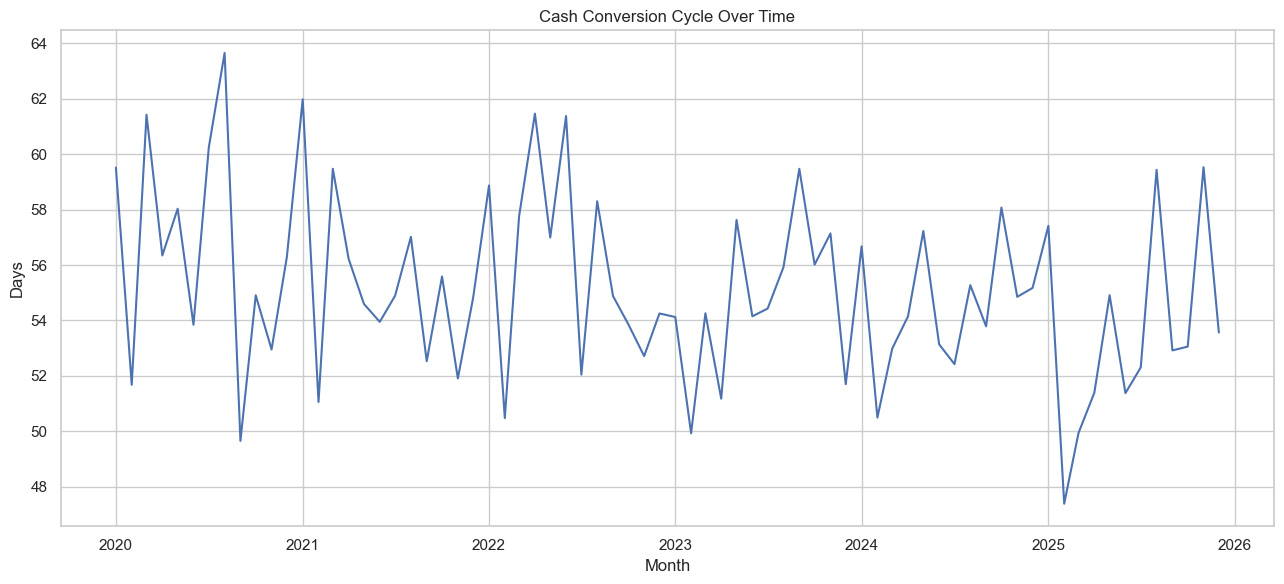

In [30]:
plt.figure(figsize=(13, 6))
sns.lineplot(data=working_capital, x="month", y="cash_conversion_cycle")
plt.title("Cash Conversion Cycle Over Time")
plt.xlabel("Month")
plt.ylabel("Days")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cash_conversion_cycle.png", dpi=300)
plt.show()

# Forecasting Analysis

### Monthly Revenue Trend and Seasonality

Before forecasting, we inspect the time series visually.

Important questions:

- Is revenue growing?
- Is there seasonality?
- Are there unusual periods?
- Does volatility change over time?

In [31]:
financials.head()

,month,revenue,cogs,gross_profit,units,active_customers,return_rate,avg_days_to_collect,sales_marketing_expense,r_and_d_expense,g_and_a_expense,total_opex,ebitda,depreciation_amortization,operating_income,interest_expense,tax_expense,net_income,accounts_receivable,inventory,accounts_payable,capex,free_cash_flow,gross_margin,ebitda_margin,net_margin
0,2020-01-01,"7,876,820.54","3,853,402.07","4,023,418.54",6599,1691,0.05,50.45,"1,185,084.94","633,567.35","956,421.25","2,775,073.54","1,248,345.00","192,734.55","1,055,610.45","88,969.38","170,190.05","796,451.02","13,245,047.65","2,712,945.98","1,794,554.01","365,914.29","623,271.28",0.51,0.16,0.10
1,2020-02-01,"8,249,437.24","4,057,691.40","4,191,745.55",6376,1611,0.04,49.75,"1,256,457.88","771,306.84","884,015.96","2,911,780.68","1,279,964.87","298,538.90","981,425.97","116,661.57","143,872.99","720,891.41","13,681,145.42","2,802,054.43","2,300,415.33","519,026.87","481,058.54",0.51,0.16,0.09
2,2020-03-01,"8,537,230.51","4,224,043.52","4,313,186.96",6555,1673,0.05,50.45,"1,576,113.32","985,662.71","1,164,898.99","3,726,675.02","586,511.94","247,757.66","338,754.28","99,270.72","44,337.33","195,146.23","14,356,658.80","2,880,638.48","1,614,668.60","322,269.99","-1,319,210.26",0.51,0.07,0.02
3,2020-04-01,"8,159,591.71","3,959,527.24","4,200,064.61",6315,1622,0.04,50.09,"1,420,251.51","721,040.54","1,094,596.09","3,235,888.14","964,176.47","262,129.79","702,046.68","50,312.20","149,230.13","502,504.35","13,623,132.78","2,686,172.26","1,860,299.39","158,456.15","1,779,801.02",0.51,0.12,0.06
4,2020-05-01,"8,828,964.24","4,219,678.52","4,609,285.86",6714,1649,0.04,49.90,"1,456,139.49","923,516.63","1,077,155.15","3,456,811.27","1,152,474.59","153,441.36","999,033.23","63,455.30","208,817.83","726,760.10","14,685,194.07","2,623,922.59","1,743,433.26","460,418.39","-696,894.68",0.52,0.13,0.08


In [32]:
monthly_revenue = financials[["month", "revenue"]].copy()
monthly_revenue["year"] = monthly_revenue["month"].dt.year
monthly_revenue["month_num"] = monthly_revenue["month"].dt.month
monthly_revenue["month_name"] = monthly_revenue["month"].dt.month_name()
monthly_revenue["revenue_growth"] = monthly_revenue["revenue"].pct_change()

monthly_revenue.head()

,month,revenue,year,month_num,month_name,revenue_growth
0,2020-01-01,"7,876,820.54",2020,1,January,NaN
1,2020-02-01,"8,249,437.24",2020,2,February,0.05
2,2020-03-01,"8,537,230.51",2020,3,March,0.03
3,2020-04-01,"8,159,591.71",2020,4,April,-0.04
4,2020-05-01,"8,828,964.24",2020,5,May,0.08


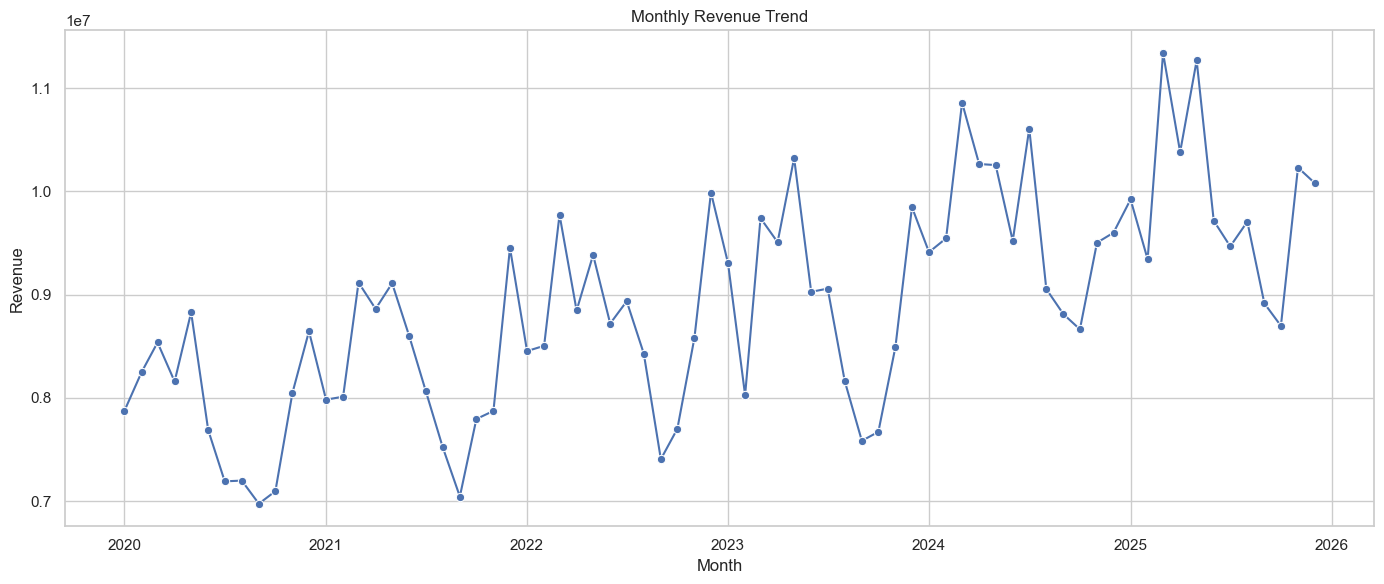

In [33]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_revenue, x="month", y="revenue", marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "monthly_revenue_trend.png", dpi=300)
plt.show()

In [34]:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

seasonality = (
    monthly_revenue
    .groupby("month_name", as_index=False)
    .agg(avg_revenue=("revenue", "mean"))
)
seasonality.head()

,month_name,avg_revenue
0,April,"9,336,871.32"
1,August,"8,345,801.03"
2,December,"9,602,695.47"
3,February,"8,613,544.93"
4,January,"8,825,226.92"


In [35]:
seasonality["month_name"] = pd.Categorical(
    seasonality["month_name"],
    categories=month_order,
    ordered=True
)

In [37]:
seasonality = seasonality.sort_values("month_name")
seasonality.head()

,month_name,avg_revenue
4,January,"8,825,226.92"
3,February,"8,613,544.93"
7,March,"9,894,578.66"
0,April,"9,336,871.32"
8,May,"9,861,366.29"


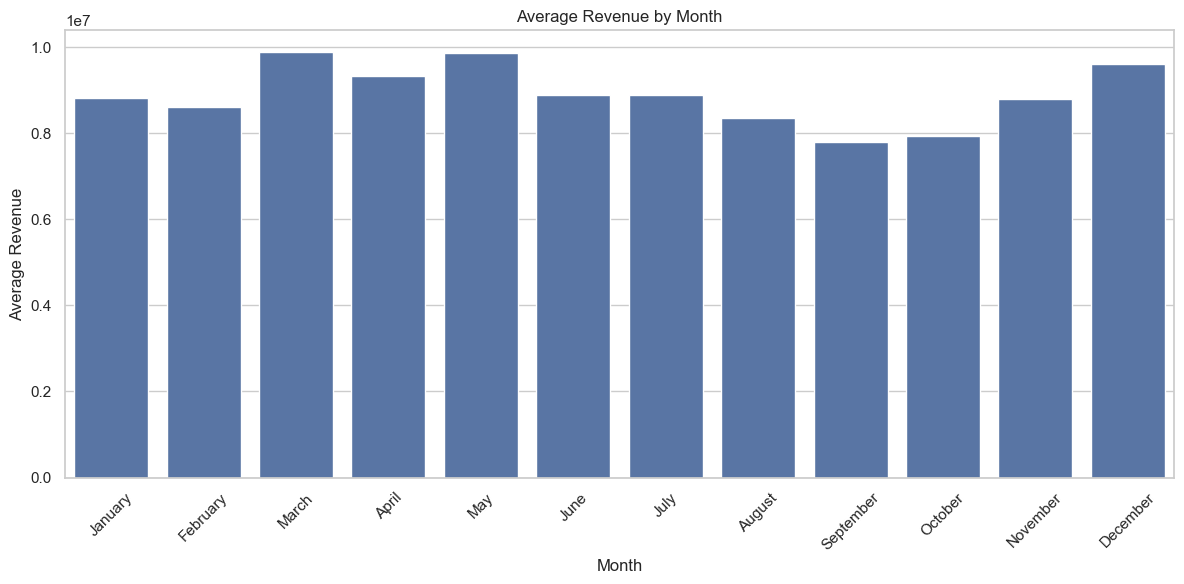

In [36]:
plt.figure(figsize=(12, 6))
sns.barplot(data=seasonality, x="month_name", y="avg_revenue")
plt.title("Average Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Average Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "average_revenue_by_month.png", dpi=300)
plt.show()

### The forecasting part is in the forecasting.ipynb file.